Iniciando simulación...
Ruido: 0.0% | QBER: 0.0000 | Tasa de Clave Secreta: 1.0000
Ruido: 1.4% | QBER: 0.0068 | Tasa de Clave Secreta: 0.8819
Ruido: 2.9% | QBER: 0.0128 | Tasa de Clave Secreta: 0.8018
Ruido: 4.3% | QBER: 0.0256 | Tasa de Clave Secreta: 0.6561
Ruido: 5.7% | QBER: 0.0310 | Tasa de Clave Secreta: 0.6012
Ruido: 7.1% | QBER: 0.0447 | Tasa de Clave Secreta: 0.4727
Ruido: 8.6% | QBER: 0.0585 | Tasa de Clave Secreta: 0.3573
Ruido: 10.0% | QBER: 0.0762 | Tasa de Clave Secreta: 0.2224
Ruido: 11.4% | QBER: 0.0794 | Tasa de Clave Secreta: 0.1997
Ruido: 12.9% | QBER: 0.0937 | Tasa de Clave Secreta: 0.1026
Ruido: 14.3% | QBER: 0.0858 | Tasa de Clave Secreta: 0.1556
Ruido: 15.7% | QBER: 0.1059 | Tasa de Clave Secreta: 0.0254
Ruido: 17.1% | QBER: 0.1063 | Tasa de Clave Secreta: 0.0230
Ruido: 18.6% | QBER: 0.1245 | Tasa de Clave Secreta: 0.0000
Ruido: 20.0% | QBER: 0.1383 | Tasa de Clave Secreta: 0.0000
Simulación completada.


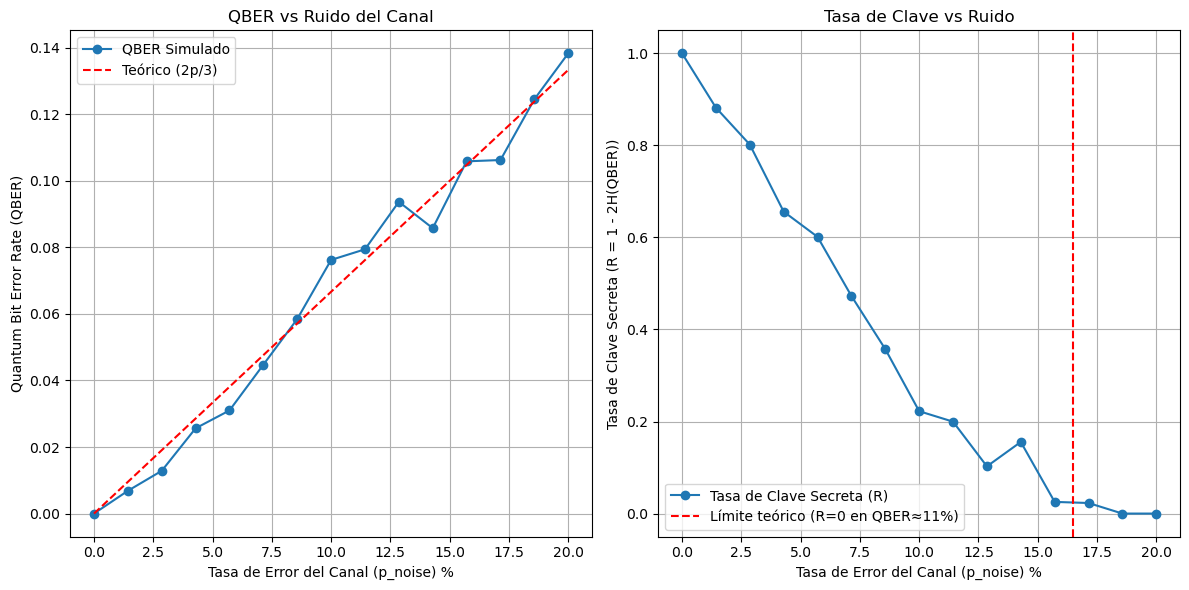

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- CAMBIOS EN LA IMPORTACIÓN ---
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator # Importación corregida
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.quantum_info import state_fidelity

# --- Configuración del Backend ---
# Usamos el simulador directamente
backend_sim = AerSimulator()

# --- Funciones de Codificación y Medición ---

def encode_bb84(bits, bases):
    """Codifica los bits de Alice en qubits según sus bases."""
    qc = QuantumCircuit(1, 1) # 1 qubit, 1 classical bit
    if bits == 1:
        qc.x(0)
    if bases == 1:
        qc.h(0)
    return qc

def measure_bb84(qc, basis):
    """Mide el qubit de Alice en la base elegida por Bob."""
    if basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    return qc

# --- Función del Canal Ruidoso ---

def create_noise_model(p_noise):
    """Crea un modelo de ruido simple (canal de Pauli simétrico)."""
    p_x = p_noise / 3
    p_y = p_noise / 3
    p_z = p_noise / 3
    error_gate = pauli_error([('X', p_x), ('Y', p_y), ('Z', p_z), ('I', 1 - p_noise)])
    
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(error_gate, ['id']) 
    return noise_model

# --- Función de Entropía (Para Tasa de Clave) ---

def H(p):
    """Función de entropía binaria de Shannon H(p)."""
    if p == 0 or p == 1:
        return 0
    p = np.clip(p, 1e-10, 1 - 1e-10) 
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)

# --- Función Principal de Simulación BB84 ---

def run_bb84_simulation(N_bits, p_noise):
    """Ejecuta una simulación completa de BB84."""
    
    # 1. Generación (Alice y Bob)
    alice_bits = np.random.randint(0, 2, N_bits)
    alice_bases = np.random.randint(0, 2, N_bits)
    bob_bases = np.random.randint(0, 2, N_bits)
    
    # Obtenemos el backend y el modelo de ruido
    simulator = AerSimulator() # Corregido
    noise_model = create_noise_model(p_noise)
    
    # Crear la lista de circuitos para ejecutar en batch
    circuits = []
    for i in range(N_bits):
        qc = encode_bb84(alice_bits[i], alice_bases[i])
        qc.id(0) # Canal ruidoso
        qc.barrier()
        qc_measure = measure_bb84(qc, bob_bases[i])
        circuits.append(qc_measure)

    # 5. Ejecución ruidosa (en batch) - Corregido para no usar 'execute'
    job = simulator.run(circuits, noise_model=noise_model, shots=1)
    result = job.result()
    
    # Procesar resultados
    bob_results = []
    for i in range(N_bits):
        counts = result.get_counts(i)
        measured_bit = int(list(counts.keys())[0])
        bob_results.append(measured_bit)
    
    bob_results = np.array(bob_results)
    
    # --- Post-Procesamiento ---
    
    # 6. Sifting
    matching_bases_idx = (alice_bases == bob_bases)
    if not np.any(matching_bases_idx):
        return 0, 0, 0 
    
    alice_sifted = alice_bits[matching_bases_idx]
    bob_sifted = bob_results[matching_bases_idx]
    
    # 7. Estimación de QBER
    errors = (alice_sifted != bob_sifted)
    n_errors = np.sum(errors)
    n_sifted = len(alice_sifted)
    
    if n_sifted == 0:
        return 0, 0, 0
        
    qber = n_errors / n_sifted
    
    # 8. Cálculo de Tasa
    secret_key_rate = max(0, 1 - 2 * H(qber))
    
    return qber, secret_key_rate, n_sifted

# --- Experimento y Graficación ---

# Parámetros del experimento
N_bits_total = 4000 
noise_levels = np.linspace(0, 0.20, 15)

qber_results = []
rate_results = []

print("Iniciando simulación...")

for p in noise_levels:
    qber, rate, _ = run_bb84_simulation(N_bits_total, p)
    qber_results.append(qber)
    rate_results.append(rate)
    print(f"Ruido: {p*100:.1f}% | QBER: {qber:.4f} | Tasa de Clave Secreta: {rate:.4f}")

print("Simulación completada.")

# --- Graficación ---

plt.figure(figsize=(12, 6))

# Gráfica 1: QBER vs Ruido
plt.subplot(1, 2, 1)
plt.plot(noise_levels * 100, qber_results, 'o-', label='QBER Simulado')
plt.plot(noise_levels * 100, (2/3) * noise_levels, 'r--', label='Teórico (2p/3)')
plt.title('QBER vs Ruido del Canal')
plt.xlabel('Tasa de Error del Canal (p_noise) %')
plt.ylabel('Quantum Bit Error Rate (QBER)')
plt.legend()
plt.grid(True)

# Gráfica 2: Tasa de Clave vs Ruido
plt.subplot(1, 2, 2)
plt.plot(noise_levels * 100, rate_results, 'o-', label='Tasa de Clave Secreta (R)')
qber_lim = 0.110 
plt.axvline(qber_lim * (3/2) * 100, color='red', linestyle='--', label=f'Límite teórico (R=0 en QBER≈11%)')
plt.title('Tasa de Clave vs Ruido')
plt.xlabel('Tasa de Error del Canal (p_noise) %')
plt.ylabel('Tasa de Clave Secreta (R = 1 - 2H(QBER))')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()